In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)   # 显示所有列
pd.set_option('expand_frame_repr', False)   # 不允许换行
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.max_colwidth', None)
train_data = pd.read_csv('/kaggle/input/titanic/train.csv')
test_data = pd.read_csv('/kaggle/input/titanic/test.csv')
train_data.info()  
test_data.info()
print('train_data中的缺失值：', train_data.isnull().sum())
print('test_data中的缺失值：', test_data.isnull().sum())
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean())
test_data['Age'] = test_data['Age'].fillna(test_data['Age'].mean())
train_data['Cabin'] = train_data['Cabin'].fillna(method='bfill') # bfill表示后一个值
train_data['Cabin'] = train_data['Cabin'].fillna(method='ffill') # ffill表示前一个值
test_data['Cabin'] = test_data['Cabin'].fillna(method='bfill')
test_data['Cabin'] = test_data['Cabin'].fillna(method='ffill')
train_data['Embarked'] = train_data['Embarked'].fillna('S')
train_data['Embarked'].value_counts()
test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].mean())
full_data = pd.concat([train_data, test_data], axis=0).reset_index()
full_data = full_data.drop('index', axis=1)

print('full_data中的缺失值：', full_data.isnull().sum())
Sex_mapDict = {'male' : 1, 'female' : 0}
full_data['Sex'] = full_data['Sex'].map(Sex_mapDict)
full_data['Sex'] = full_data['Sex'].map({'male':1, 'female':0})
Pclass_df = pd.DataFrame()
Pclass_df = pd.get_dummies(full_data['Pclass'], prefix='Pclass')
full_data = pd.concat([full_data, Pclass_df], axis=1)
full_data = full_data.drop('Pclass', axis=1)
Embarked_df = pd.DataFrame()
Embarked_df = pd.get_dummies(full_data['Embarked'], prefix='Embarked')
full_data = pd.concat([full_data, Embarked_df], axis=1)
full_data = full_data.drop('Embarked', axis=1)
def GetTitle(name):              # 编写一个新的函数
    str1 = name.split(',')[1]    # 用逗号进行分割，1代表取后半部分
    str2 = str1.split('.')[0]    # 用句号进行分割，0代表取前半部分
    str3 = str2.strip()          # strip()用于移除指定的符号，这里默认为空格  
    return str3

Name_df = pd.DataFrame()
Name_df['Title'] = full_data['Name'].map(GetTitle)  # 再次用上述的map函数，将GetTitle映射到列['Name']

#  这一步，像Mr、Miss的就是正确的头衔，而Mlle、Dona等可能要进行自我判断一下，这里把所有的值都统一到几个常见的头衔
Title_mapDict = {'Mr': 'Mr',
                 'Miss': 'Miss',
                 'Mrs': 'Mrs',
                 'Master': 'Master',
                 'Dr': 'Officer',
                 'Rev': 'Officer',
                 'Col': 'Officer',
                 'Ms': 'Mrs',
                 'Major': 'Officer',
                 'Mlle': 'Miss',
                 'Jonkheer': 'Mr',
                 'Don': 'Mr',
                 'Lady': 'Mrs',
                 'the Countess': 'Royalty',
                 'Dona': 'Royalty',
                 'Capt': 'Royalty',
                 'Sir': 'Officer',
                 'Mme': 'Royalty',
                 }

Name_df['Title'] = Name_df['Title'].map(Title_mapDict)
Name_df = pd.get_dummies(Name_df['Title'], prefix='Title')
full_data = pd.concat([full_data, Name_df], axis=1)
full_data = full_data.drop('Name', axis=1)
full_data['Cabin'] = full_data['Cabin'].astype(str)            # 首先将这列转换为字符串类型
full_data['Cabin'] = full_data['Cabin'].map(lambda x : x[0])   # 接着用lambda函数实现提取首字符

Cabin_df = pd.DataFrame()
Cabin_df = pd.get_dummies(full_data['Cabin'], prefix='Cabin')

full_data = pd.concat([full_data, Cabin_df], axis=1)
full_data = full_data.drop('Cabin', axis=1)
Family_df = pd.DataFrame()
Family_df['Family'] = full_data['Parch'] + full_data['SibSp'] + 1
Family_df['Family_S'] = Family_df['Family'].map(lambda x : 1 if x == 1 else 0)
Family_df['Family_M'] = Family_df['Family'].map(lambda x : 1 if 2 <= x <= 3 else 0)
Family_df['Family_L'] = Family_df['Family'].map(lambda x : 1 if 4 < x < 5 else 0)
Family_df['Family_Xl'] = Family_df['Family'].map(lambda x : 1 if 5 < x else 0)


Family_df = Family_df.iloc[:, 1:]
full_data = pd.concat([full_data, Family_df], axis=1)
Fare_df = pd.DataFrame()
Fare_df['Fare'] = full_data['Fare']
Fare_df['Fare_Low'] = Fare_df['Fare'].map(lambda x : 1 if 0 <= x < 50 else 0)
Fare_df['Fare_Medium'] = Fare_df['Fare'].map(lambda x : 1 if 50 <= x < 100 else 0)
Fare_df['Fare_High'] = Fare_df['Fare'].map(lambda x : 1 if 100 < x else 0)

Fare_df = Fare_df.iloc[:, 1:]

full_data = pd.concat([full_data, Fare_df], axis=1)
full_data = full_data.drop('Fare', axis=1)
full_X = full_data.drop('PassengerId',axis=1)
full_X = full_X.drop('SibSp', axis=1)
full_X = full_X.drop('Parch', axis=1)
full_X = full_X.drop('Ticket', axis=1)
Row = 890
train_X = full_X.loc[0:Row, :]                 # 前891行，即原train数据集行数
train_X = train_X.drop('Survived', axis=1)     # 剔除'Survived'列
train_y = full_X.loc[0:Row, 'Survived']        # 原始train数据集行数

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass  

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END max_depth=3, min_samples_split=2, n_estimators=50, random_state=42; total time=   0.2s
[CV] END max_depth=3, min_samples_split=2, n_estimators=50, random_state=42; total time=   0.2s
[CV] END max_depth=3, min_samples_split=2, n_estimators=50, random_state=42; total time=   0.2s
[CV] END max_depth=3, min_samples_split=2, n_estimators=50, random_state=42; total time=   0.2s
[CV] END max_depth=3, min_samples_split=2, n_estimators=50, random_state=42; total time=   0.2s
[CV] END max_depth=3, min_samples_split=2, n_estimators=100, random_state=42; total time=   0.4s
[CV] END max_depth=3, min_samples_split=2, n_estimators=100, random_state=42; total time=   0.4s
[CV] END max_depth=3, min_samples_split=2, n_estimators=100, random_state=42; total time=   0.4s
[CV] END max_depth=3, min_samples_split=2, n_estimators=100, random_state=42; total time=   0.4s
[CV] END max_depth=3, min_samples_split=2, n_estimators=100, random_st

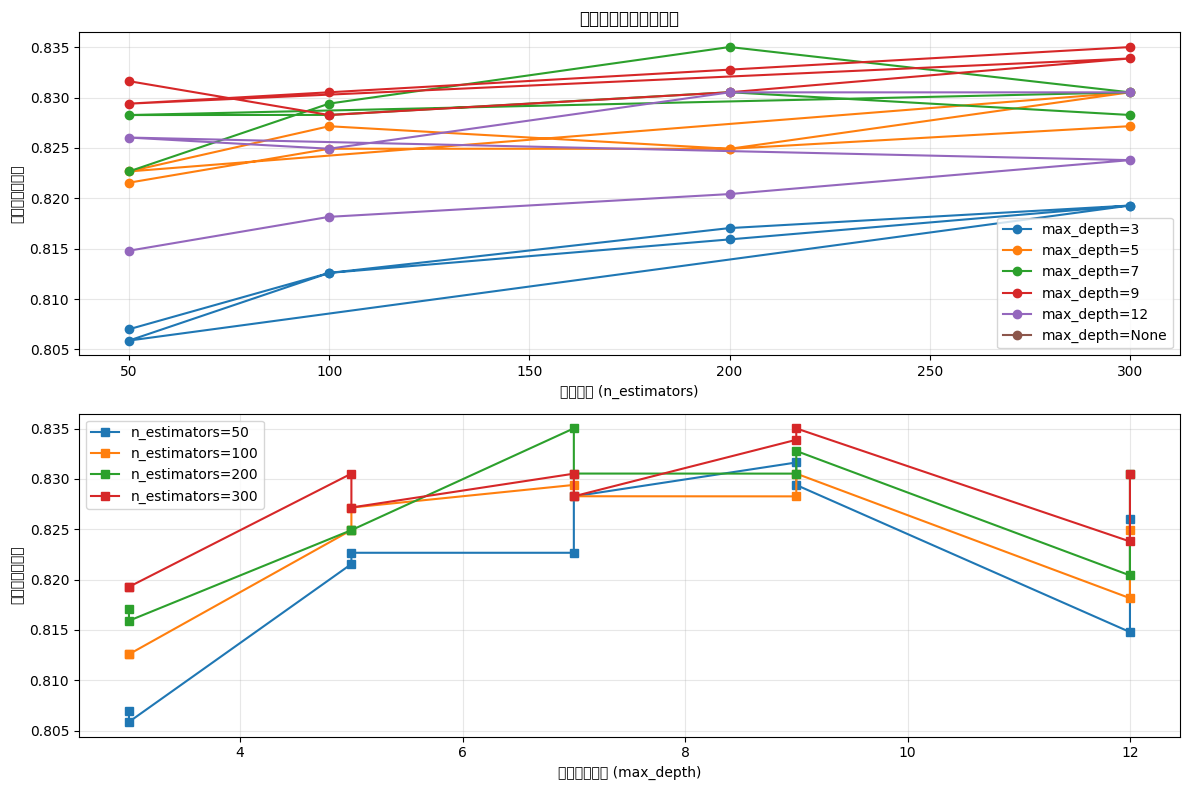

预测结果已保存至 titanic_rf_submission.csv
参数可视化图已保存为 rf_param_visualization.png


In [3]:
#随机森林算法
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# 数据加载
train_data = pd.read_csv('/kaggle/input/titanic/train.csv')
test_data = pd.read_csv('/kaggle/input/titanic/test.csv')

# 合并数据便于统一处理
full_data = pd.concat([train_data, test_data], axis=0, ignore_index=True)

# -------------------- 1. 数据清洗 --------------------
# 填充缺失值
full_data['Age'] = full_data['Age'].fillna(full_data['Age'].median())
full_data['Fare'] = full_data['Fare'].fillna(full_data['Fare'].median())
full_data['Embarked'] = full_data['Embarked'].fillna('S')

# 处理Cabin（提取首字母并标记缺失值）
full_data['Cabin'] = full_data['Cabin'].apply(lambda x: x[0] if pd.notna(x) else 'Unknown')

# -------------------- 2. 特征工程 --------------------
# 性别编码
full_data['Sex'] = full_data['Sex'].map({'male': 1, 'female': 0})

# 独热编码：Pclass, Embarked, Cabin
full_data = pd.get_dummies(full_data, columns=['Pclass', 'Embarked', 'Cabin'], prefix=['Pclass', 'Embarked', 'Cabin'])

# 从Name中提取Title
full_data['Title'] = full_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
title_mapping = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Dr': 'Officer', 'Rev': 'Officer', 'Col': 'Officer', 'Mlle': 'Miss',
    'Major': 'Officer', 'Ms': 'Mrs', 'Lady': 'Mrs', 'Sir': 'Officer',
    'Mme': 'Mrs', 'Countess': 'Royalty', 'Don': 'Royalty', 'Dona': 'Royalty'
}
full_data['Title'] = full_data['Title'].map(title_mapping)
full_data = pd.get_dummies(full_data, columns=['Title'], prefix='Title')

# 构造家庭规模特征
full_data['FamilySize'] = full_data['SibSp'] + full_data['Parch'] + 1
full_data['IsAlone'] = (full_data['FamilySize'] == 1).astype(int)

# 删除无用列
drop_columns = ['Name', 'Ticket', 'SibSp', 'Parch', 'PassengerId']
full_data = full_data.drop(drop_columns, axis=1)

# -------------------- 3. 数据分割 --------------------
# 恢复训练集和测试集
train = full_data[~full_data['Survived'].isna()]
test = full_data[full_data['Survived'].isna()].drop('Survived', axis=1)

X = train.drop('Survived', axis=1)
y = train['Survived']
# -------------------- 4. 随机森林模型参数调优 --------------------
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# 定义参数网格（可根据需求调整取值范围）
param_grid = {
    'n_estimators': [50,100, 200, 300],  # 树的数量
    'max_depth': [3, 5, 7, 9,12,None],      # 树的最大深度
    'min_samples_split': [2, 5],      # 节点分裂最小样本数
    'random_state': [42]
}

# 初始化网格搜索（5折交叉验证）
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=2
)

# 执行参数搜索
grid_search.fit(X, y)

# 输出最优参数和性能
best_params = grid_search.best_params_
best_accuracy = grid_search.best_score_
print(f"最优参数: {best_params}")
print(f"交叉验证最高准确率: {best_accuracy:.4f}")

# -------------------- 可视化参数影响 --------------------
# 转换搜索结果为DataFrame
results = pd.DataFrame(grid_search.cv_results_)

# 绘制不同树数量的性能对比（按深度分组）
plt.figure(figsize=(12, 8))

# 子图1：n_estimators与准确率的关系（不同max_depth）
plt.subplot(2, 1, 1)
for depth in results['param_max_depth'].unique():
    subset = results[results['param_max_depth'] == depth]
    plt.plot(subset['param_n_estimators'], subset['mean_test_score'], 
             marker='o', label=f'max_depth={depth}')
plt.xlabel('树的数量 (n_estimators)')
plt.ylabel('交叉验证准确率')
plt.title('随机森林参数性能对比')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图2：max_depth与准确率的关系（不同n_estimators）
plt.subplot(2, 1, 2)
for n_est in results['param_n_estimators'].unique():
    subset = results[results['param_n_estimators'] == n_est]
    plt.plot(subset['param_max_depth'], subset['mean_test_score'], 
             marker='s', label=f'n_estimators={n_est}')
plt.xlabel('树的最大深度 (max_depth)')
plt.ylabel('交叉验证准确率')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rf_param_visualization.png', dpi=300)  # 保存图片
plt.show()

# -------------------- 5. 训练与输出 --------------------
# 使用最优参数初始化模型
rf_model = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    random_state=42,
    n_jobs=-1
)

# 训练最终模型
rf_model.fit(X, y)

# 预测测试集
test_predictions = rf_model.predict(test)

# 生成提交文件
submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': test_predictions.astype(int)
})
submission.to_csv('titanic_rf_submission.csv', index=False)
print("预测结果已保存至 titanic_rf_submission.csv")
print("参数可视化图已保存为 rf_param_visualization.png")